# Week 2 — Day 2: Probability & Distributions

This notebook applies the main probability rules through NumPy simulations and introduces three common probability distributions used in data analysis and machine learning.

## Learning Objectives

- Apply the complement, addition, and multiplication rules of probability.
- Calculate conditional probability.
- Understand how Bayes' theorem reverses a conditional probability.
- Recognize normal, uniform, and binomial distributions.
- Compare experimental probability with theoretical probability.

## 1. Import Libraries

NumPy is used for simulations and random sampling, Pandas is used for tabular data, and Matplotlib is used to visualize the distributions.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# A fixed seed makes the random results reproducible.
np.random.seed(40)

## 2. Basic Random Operations

These examples show how NumPy can generate values from a uniform distribution, select random categories, shuffle numbers, generate die rolls, count outcomes, and return random decimal values.

In [2]:
# Random values from a continuous uniform distribution
uniform_sample = np.random.uniform(1, 7, 10)
print("Uniform sample:", uniform_sample)

# Random selection from categories
colors = ["Red", "Blue", "Green", "Black"]
selected_colors = np.random.choice(colors, 20)
print("\nSelected colors:", selected_colors)

# Random permutation
numbers = np.arange(1, 11)
shuffled_numbers = np.random.permutation(numbers)
print("\nOriginal numbers:", numbers)
print("Shuffled numbers:", shuffled_numbers)

# Random die rolls and their frequencies
small_dice_sample = np.random.randint(1, 7, 20)
values, counts = np.unique(small_dice_sample, return_counts=True)
print("\nDie rolls:", small_dice_sample)
print("Values:", values)
print("Counts:", counts)

# Random decimal values between 0 and 1
print("\nRandom value 1:", np.random.rand())
print("Random value 2:", np.random.rand())

Uniform sample: [3.44612217 1.33219624 5.73120926 2.72383111 3.70210352 2.82347383
 4.15839715 4.74287328 5.66065275 5.11744987]

Selected colors: ['Blue' 'Blue' 'Blue' 'Red' 'Red' 'Green' 'Black' 'Green' 'Red' 'Red'
 'Red' 'Green' 'Green' 'Green' 'Black' 'Black' 'Black' 'Black' 'Black'
 'Blue']

Original numbers: [ 1  2  3  4  5  6  7  8  9 10]
Shuffled numbers: [ 2  5  1  9 10  7  8  3  6  4]

Die rolls: [2 4 4 3 3 3 5 6 1 2 5 2 4 4 1 6 6 2 4 3]
Values: [1 2 3 4 5 6]
Counts: [2 4 4 5 2 3]

Random value 1: 0.03665485277358338
Random value 2: 0.5685447571589641


The fixed seed ensures that the same random sequence is produced whenever the notebook is restarted and executed from the beginning.

## 3. Coin Flip Simulation

For a fair coin:

$P(H) = 0.5, \qquad P(T) = 0.5$

As the number of trials becomes large, the experimental proportions should approach the theoretical probabilities.

In [3]:
record1 = np.random.choice(["H", "T"], 10000)
record2 = np.random.choice(["H", "T"], 10000)

heads = np.sum(record1 == "H")
tails = np.sum(record1 == "T")

p_heads = heads / len(record1)
p_tails = tails / len(record1)

print("First 20 results:", record1[:20])
print("Experimental P(H):", p_heads)
print("Experimental P(T):", p_tails)
print("Theoretical P(H):", 0.5)
print("Theoretical P(T):", 0.5)

First 20 results: ['T' 'T' 'H' 'T' 'T' 'H' 'T' 'H' 'H' 'H' 'T' 'T' 'H' 'H' 'T' 'H' 'H' 'T'
 'H' 'T']
Experimental P(H): 0.4934
Experimental P(T): 0.5066
Theoretical P(H): 0.5
Theoretical P(T): 0.5


The proportions are expected to be close to 0.5, although they may not be exactly equal because the experiment is random.

## 4. Die Roll Probability

For a fair six-sided die, the theoretical probability of rolling any specific number is:

$P(X = 4) = \frac{1}{6}$

In [4]:
dice = np.random.randint(1, 7, 10000)

p4 = np.mean(dice == 4)

print("Experimental P(4):", p4)
print("Theoretical P(4):", 1 / 6)

Experimental P(4): 0.1669
Theoretical P(4): 0.16666666666666666


The experimental probability should approach $\frac{1}{6}$ as the number of simulated rolls increases.

## 5. Complement Rule

The complement rule is:

$$P(\text{not } A) = 1 - P(A)$$

For the event of rolling 4, the event's complement is not rolling 4.

In [5]:
not_p4 = np.mean(dice != 4)

print("P(4):", p4)
print("P(not 4):", not_p4)
print("P(4) + P(not 4):", p4 + not_p4)

P(4): 0.1669
P(not 4): 0.8331
P(4) + P(not 4): 1.0


The two probabilities add up to 1 because rolling 4 and not rolling 4 cover all possible outcomes.

## 6. Addition Rule

For two events that may overlap:

$$P(A \cup B) = P(A) + P(B) - P(A \cap B)$$

Let:

- \(A\): the die result is even.
- \(B\): the die result is greater than 4.

In [6]:
A = dice % 2 == 0
B = dice > 4

pA = np.mean(A)
pB = np.mean(B)
pAB = np.mean(A & B)

p_union_formula = pA + pB - pAB
p_union_direct = np.mean(A | B)

print("P(A):", pA)
print("P(B):", pB)
print("P(A and B):", pAB)
print("P(A or B) using the formula:", p_union_formula)
print("P(A or B) directly:", p_union_direct)

P(A): 0.5037
P(B): 0.3302
P(A and B): 0.168
P(A or B) using the formula: 0.6659
P(A or B) directly: 0.6659


Both methods produce the same result. The intersection is subtracted because it is counted once in \(P(A)\) and once again in \(P(B)\).

## 7. Multiplication Rule for Independent Events

For two independent events:

$P(A \cap B) = P(A) \times P(B)$

The probability of getting heads in two independent fair coin flips is:

$0.5 \times 0.5 = 0.25$

In [7]:
p_two_heads_experimental = np.mean((record1 == "H") & (record2 == "H"))

p_two_heads_theoretical = 0.5 * 0.5

print("Experimental P(H and H):", p_two_heads_experimental)
print("Theoretical P(H and H):", p_two_heads_theoretical)

Experimental P(H and H): 0.2442
Theoretical P(H and H): 0.25


The simulated result should be close to 0.25, which supports the multiplication rule for independent events.

## 8. Conditional Probability

Conditional probability measures the probability of event \(A\) after event \(B\) is already known:

$$P(A \mid B) = \frac{P(A \cap B)}{P(B)}$$

The following small dataset is used to calculate the probability that a student passed given that the student is male.

In [8]:
data_frame = pd.DataFrame({
    "Gender": ["F", "M", "M", "F", "F", "M", "M", "M", "F"],
    "Passed": [1, 0, 1, 0, 1, 1, 0, 1, 1]
})


male_students = data_frame[data_frame["Gender"] == "M"]
p_passed_given_male = np.mean(male_students["Passed"] == 1)

print("P(Passed | Male):", p_passed_given_male)

P(Passed | Male): 0.6


The calculation first filters the dataset to male students, then finds the proportion of those students who passed.

## 9. Bayes' Theorem

Bayes' theorem reverses a conditional probability:

$$P(A \mid B) = \frac{P(B \mid A) \times P(A)}{P(B)}$$

Here, $P(\text{Passed} \mid \text{Male})$ is calculated again using:

$$P(\text{Passed} \mid \text{Male}) = \frac{P(\text{Male} \mid \text{Passed}) \times P(\text{Passed})}{P(\text{Male})}$$

In [9]:
p_male_given_passed = np.mean( data_frame[data_frame["Passed"] == 1]["Gender"] == "M")
p_passed = np.mean(data_frame["Passed"] == 1)
p_male = np.mean(data_frame["Gender"] == "M")

p_passed_given_male_bayes = (p_male_given_passed * p_passed / p_male)

print("Direct P(Passed | Male):", p_passed_given_male)
print("Bayes P(Passed | Male):", p_passed_given_male_bayes)

Direct P(Passed | Male): 0.6
Bayes P(Passed | Male): 0.6


The direct calculation and Bayes' theorem give the same probability.

## 10. Normal Distribution

A normal distribution is symmetric and bell-shaped. Many measurements are approximately normal, such as human heights and measurement errors.

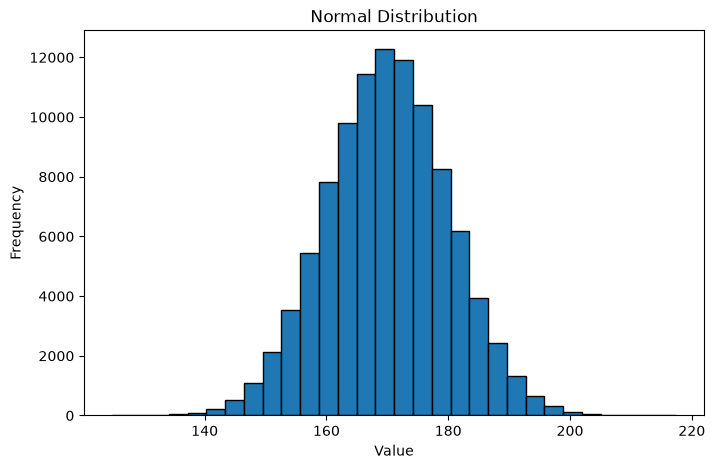

In [10]:
normal = np.random.normal( 170,10,100000)

plt.figure(figsize=(8, 5))
plt.hist(normal, bins=30, edgecolor="black")
plt.title("Normal Distribution")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()

Most generated values are concentrated around the mean of 170, while fewer values appear farther from the center.

## 11. Uniform Distribution

In a uniform distribution, every value inside the selected range has an equal chance of being generated.

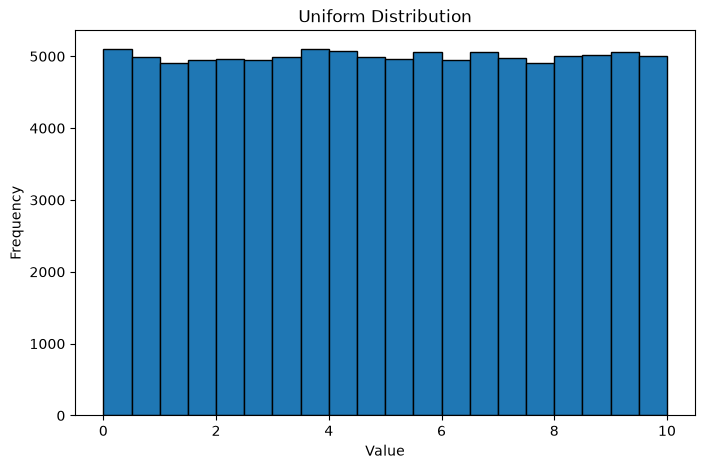

In [11]:
uniform = np.random.uniform(low=0,high=10,size=100000)

plt.figure(figsize=(8, 5))
plt.hist(uniform, bins=20, edgecolor="black")
plt.title("Uniform Distribution")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()

The histogram is approximately flat because values between 0 and 10 are equally likely.

## 12. Binomial Distribution

A binomial distribution describes the number of successes in a fixed number of independent yes/no trials.

In this example:

- Number of trials: 10
- Probability of success: 0.5
- Number of repeated experiments: 100,000

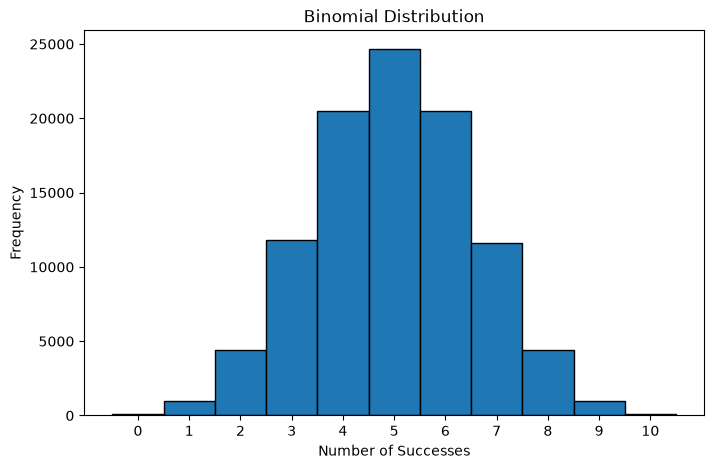

In [12]:
binomial = np.random.binomial(n=10,p=0.5,size=100000)

plt.figure(figsize=(8, 5))
plt.hist(binomial,bins=np.arange(-0.5, 11.5, 1),edgecolor="black")
plt.title("Binomial Distribution")
plt.xlabel("Number of Successes")
plt.ylabel("Frequency")
plt.xticks(range(11))
plt.show()

The values are concentrated around 5 because the expected number of successes is:

$$n \times p = 10 \times 0.5 = 5$$

## 13. Random Seed Note

`np.random.seed(40)` was used at the beginning to make the results reproducible. Resetting the seed to `None` makes future random values depend on the system's random state again.

In [13]:
np.random.seed(None)

## Final Conclusion

The simulations showed that experimental probabilities approach their theoretical values when the number of trials increases. The complement, addition, and multiplication rules were verified using generated data. The conditional-probability result was also consistent with Bayes' theorem. Finally, the normal, uniform, and binomial simulations demonstrated how different probability distributions represent different types of random behavior.
